# Ultra-Scale Parallelism with Megatron Bridge on NVIDIA GPUs

<div style="background: #fafafa; border-left: 4px solid #76b900; padding: 16px 20px; margin: 16px 0; border-radius: 4px;">
<h3 style="margin-top: 0; color: #333333;">&#128203; Table of Contents</h3>

<p style="margin: 4px 0;"><strong>Training Tutorial (~60 min)</strong></p>
<ul style="list-style: none; padding-left: 0; margin: 4px 0 0 0;">
  <li style="margin: 4px 0;">&#9201; <a href="#introduction" style="color: #1565c0;">Introduction &mdash; Why Parallelism?</a></li>
  <li style="margin: 4px 0;">&#128640; <a href="#step-1" style="color: #1565c0;">Scale Out &amp; Optimize</a> <span style="color: #757575; font-size: 13px;">(~13 min DP + ~12 min TP + ~8 min PP + ~5 min CP + ~3 min EP)</span></li>
  <li style="margin: 4px 0;">&#9889; <a href="#step-2" style="color: #1565c0;">Optimize Memory &amp; Compute</a> <span style="color: #757575; font-size: 13px;">(~7 min recompute + ~5 min overlap)</span></li>
  <li style="margin: 4px 0;">&#128737; <a href="#step-3" style="color: #1565c0;">Add Fault Tolerance</a> <span style="color: #757575; font-size: 13px;">(~5 min checkpointing + resume)</span></li>
  <li style="margin: 4px 0;">&#9989; <a href="#training-summary" style="color: #1565c0;">Training Summary</a></li>
</ul>
</div>


---
### Intro

This tutorial is a hands-on guide to Megatron parallelism on a 4-GPU system. It is designed to show how the main training dimensions fit together in practice before you scale to larger datasets, models, and clusters.

The training path uses **Qwen3-600M** for the initial data-parallel smoke test and **Qwen3-4B** for the tensor, pipeline, context-parallel, checkpoint, and resume sections. You will work through data parallelism, Tensor Parallel, Pipeline Parallel, Context Parallel, activation recomputation, communication overlap, and distributed checkpointing using the NVIDIA Megatron stack: **Megatron Core** for the distributed building blocks, **Megatron-LM** for the training runtime, and **Megatron Bridge** for Qwen3 recipes and checkpoint interoperability.

To keep the lab focused on systems behavior instead of dataset preparation, the training runs below use Megatron Bridge Qwen3 recipes with **mock data** and short 10-step jobs. The same entrypoints can be pointed at a real dataset later.

For broader background on large-scale training tradeoffs, see Hugging Face's [Ultra-Scale Playbook](https://huggingface.co/spaces/nanotron/ultrascale-playbook?section=high-level_overview) and its [cheatsheet](https://nanotron-ultrascale-playbook.static.hf.space/assets/images/ultra-cheatsheet.svg). For Megatron Bridge performance numbers and example configs across different GPU platforms, see the [Megatron Bridge performance summary](https://docs.nvidia.com/nemo/megatron-bridge/latest/performance-summary.html).


### Prerequisites

- A multi-GPU machine with at least 4 NVIDIA GPUs. For best results, use modern 80GB GPUs such as **H100 80GB**.
- Local checkouts mounted at `/workspace/Megatron-LM` and `/workspace/Megatron-Bridge`.
- A recent PyTorch container or environment with CUDA enabled. The validation runs for this notebook used `nvcr.io/nvidia/pytorch:26.02-py3`.
- Enough disk space for Megatron checkpoints and exported Hugging Face weights under `/workspace/megatron-results`.


In [ ]:
! python3 -m torch.utils.collect_env


In [ ]:
import os
os.chdir("/workspace/Megatron-Bridge/tutorials/training")

! pwd
! test -d /workspace/Megatron-LM && test -d /workspace/Megatron-Bridge
! test -f pretrain_qwen3_4b_lab.py && test -f pretrain_qwen3_600m_lab.py
! pip install -e /workspace/Megatron-LM
! pip install --no-deps -e /workspace/Megatron-Bridge
! pip install transformers omegaconf hydra-core accelerate pyyaml six rich megatron-energon
! python3 -c "import megatron.core, megatron.bridge; from megatron.bridge.recipes.qwen import qwen3_4b_pretrain_config; cfg = qwen3_4b_pretrain_config(); print('Megatron Core + Megatron Bridge ready:', type(cfg).__name__)"
! git -C /workspace/Megatron-LM log -1 --pretty=format:"Megatron-LM %h | %an | %ad | %s"
! echo
! git -C /workspace/Megatron-Bridge log -1 --pretty=format:"Megatron-Bridge %h | %an | %ad | %s"
! ls -1 pretrain_qwen3_*_lab.py


<a id="introduction"></a>

---

# Introduction

### Why do we need parallelism?

Let's break down the memory requirements for training Qwen3-4B (4 billion parameters):

| Component | Calculation | Memory |
|-----------|------------|--------|
| **Model parameters** (bf16) | 4B × 2 bytes | **~8 GB** |
| **Optimizer states** (Adam, fp32 momentum + variance) | 4B × 4 bytes × 2 | **~32 GB** |
| **Gradients** (bf16) | 4B × 2 bytes | **~8 GB** |
| **Activations and runtime buffers** (varies with batch/seq) | variable | **~10-30+ GB** |
| **Total (without activations)** | | **~48 GB** |

A single modern 80GB GPU can hold Qwen3-4B at modest settings, but we still use multiple GPUs in this lab because parallelism creates headroom for longer sequences, distributed optimizer state, checkpointing, and better throughput.

### Parallelism strategy overview

The following table summarizes the key parallelism techniques we'll cover (adapted from [HF Ultra-Scale Playbook Ch.8](https://huggingface.co/spaces/nanotron/ultrascale-playbook?section=high-level_overview)):

| Technique | What it splits | Across | Communication | Best for |
|-----------|---------------|--------|---------------|----------|
| **FSDP** | Params, grads, optimizer | All GPUs | all-gather, reduce-scatter | Always: baseline memory distribution |
| **TP** | Weight matrices (intra-layer) | Intra-node | all-reduce per layer | Reducing FSDP group size |
| **PP** | Layers (inter-layer) | Inter-node | point-to-point send/recv | Further reducing FSDP group |
| **CP** | Sequence dimension | Flexible | ring send/recv for KV | Long-context training |
| **EP** | MoE experts | Flexible | all-to-all token routing | MoE models only |

We will progressively compose these techniques, starting from a simple DP smoke test, then adding TP, PP, and CP on Qwen3-4B.

---

# Training Solutions for LLMs using Megatron Core

[Megatron-LM](https://github.com/NVIDIA/Megatron-LM) is NVIDIA's reference stack for large-scale transformer training. In this lab, we use **Megatron Core** for the distributed building blocks and **Megatron Bridge** for the Qwen3-4B training recipe and checkpoint workflow. This gives us a practical way to explore tensor, pipeline, context, and data parallel strategies on a model size that fits a modern 4-GPU lab system while still exercising the same Megatron Core mechanisms used in larger training and finetuning jobs.

<div style="background: #e8f4fd; border-left: 4px solid #1976d2; padding: 12px 18px; margin: 12px 0; border-radius: 4px; font-size: 16px; color: #1565c0;">
  <strong>&#9201; Estimated time for training section: ~60 minutes</strong>
</div>

<div style="margin: 16px 0;">
  <p style="font-weight: bold; margin-bottom: 6px; font-size: 14px;">Training Roadmap</p>
  <div style="display: flex; height: 28px; border-radius: 4px; overflow: hidden; font-size: 11px; font-weight: bold;">
    <div style="background: #1565c0; color: #fff; flex: 13; display: flex; align-items: center; justify-content: center;" title="DP/FSDP ~13 min">DP/FSDP</div>
    <div style="background: #1976d2; color: #fff; flex: 12; display: flex; align-items: center; justify-content: center;" title="TP ~12 min">TP</div>
    <div style="background: #1e88e5; color: #fff; flex: 8; display: flex; align-items: center; justify-content: center;" title="PP ~8 min">PP</div>
    <div style="background: #42a5f5; color: #fff; flex: 5; display: flex; align-items: center; justify-content: center;" title="CP ~5 min">CP</div>
    <div style="background: #7b1fa2; color: #fff; flex: 7; display: flex; align-items: center; justify-content: center;" title="Recompute ~7 min">Recompute</div>
    <div style="background: #9c27b0; color: #fff; flex: 5; display: flex; align-items: center; justify-content: center;" title="Overlap ~5 min">Overlap</div>
    <div style="background: #e65100; color: #fff; flex: 7; display: flex; align-items: center; justify-content: center;" title="Checkpoint + Resume ~7 min">Checkpoint + Resume</div>
  </div>
  <div style="display: flex; font-size: 10px; color: #757575; margin-top: 2px;">
    <div style="flex: 38; text-align: center;">Step 1: Scale Out (~38 min)</div>
    <div style="flex: 12; text-align: center;">Step 2 (~12 min)</div>
    <div style="flex: 7; text-align: center;">Step 3 (~7 min)</div>
  </div>
</div>

---

### Acknowledgements

This notebook adapts an earlier TorchTitan-based version of the lab into a Megatron Core and Megatron Bridge workflow. The structure and teaching approach are also informed by Hugging Face's [Ultra-Scale Playbook](https://huggingface.co/spaces/nanotron/ultrascale-playbook?section=high-level_overview).


<a id="step-1"></a>

---

<div style="background: #e8f4fd; border-left: 4px solid #1976d2; padding: 10px 15px; margin: 10px 0; border-radius: 4px; font-size: 14px; color: #1565c0;">
  <strong>&#9201; ~13 min</strong> &mdash; Data Parallel Baseline
</div>

<h2>&#128640; Scale Out and Optimize (Saturate GPU Memory)</h2>

### Start with a Data Parallel Baseline


Megatron-LM recipes typically scale a Qwen3-class model by combining **tensor parallelism first** with the remaining GPUs assigned to data parallel groups. For this notebook, the pure data-parallel baseline uses a smaller **Qwen3-600M** smoke-test recipe to establish environment health, memory, and throughput before switching to **Qwen3-4B** for the TP, PP, CP, and checkpoint sections. Qwen3-4B is small enough to be practical on this lab machine while still large enough to make Megatron parallelism choices meaningful.

Megatron Core also supports **Megatron FSDP**, which can shard optimizer state, gradients, and parameters when model-state memory becomes the bottleneck. In this notebook, the baseline command stays simple and uses 4-way data parallelism with mock data on the smaller recipe; the summary below points to the Megatron FSDP knobs if you want to push the larger recipe further.


In [ ]:
# [DP baseline on 4 GPUs]
# mock-data Qwen3-600M recipe, 10 short iterations
! CUDA_DEVICE_MAX_CONNECTIONS=1 torchrun --nproc-per-node=4 pretrain_qwen3_600m_lab.py \
    --train-iters 10 \
    --micro-batch-size 1 \
    --global-batch-size 4 \
    --seq-length 2048 \
    --log-interval 1


Let's continue with the same Qwen3-600M smoke-test workload and enable the Megatron Bridge PyTorch profiler hooks so we can inspect one profiled step before moving on to the Qwen3-4B parallelism sections. The profiler window needs a non-zero active span, so the profiled step range uses `start < end`.


In [ ]:
# profiling
! rm -rf /workspace/megatron-results/qwen3_600m/profiled_run
! CUDA_DEVICE_MAX_CONNECTIONS=1 torchrun --nproc-per-node=4 pretrain_qwen3_600m_lab.py \
    --results-dir /workspace/megatron-results/qwen3_600m/profiled_run \
    --train-iters 10 \
    --micro-batch-size 1 \
    --global-batch-size 4 \
    --seq-length 2048 \
    --log-interval 1 \
    --profile pytorch \
    --profile-step-start 9 \
    --profile-step-end 10


In [ ]:
! ln -sfn /workspace/megatron-results/qwen3_4b /dli/task/megatron_outputs


The profiled run writes traces under the Megatron results directory. A PyTorch profiler trace is emitted for the profiled ranks, which you can inspect in `chrome://tracing/` or [Perfetto](https://ui.perfetto.dev/).

By profiling and looking at the gaps in our trace, we can find bottlenecks and decide whether to add TP, PP, CP, recomputation, or more overlap.


---

<div style="background: #e8f4fd; border-left: 4px solid #1976d2; padding: 10px 15px; margin: 10px 0; border-radius: 4px; font-size: 14px; color: #1565c0;">
  <strong>&#9201; ~12 min</strong> &mdash; <span style="color: #1565c0; font-weight: bold;">Tensor Parallel (TP)</span>
</div>

### Apply Tensor Parallel

After the basic data-parallel smoke test confirms the environment and training loop are healthy, the next lever is Tensor Parallel (TP). TP splits **individual weight matrices** across GPUs (intra-layer parallelism).

**How TP works:**
- **Column-wise parallel**: Each GPU holds a subset of columns of the weight matrix, computes a partial output. No communication needed before the matmul.
- **Row-wise parallel**: Each GPU holds a subset of rows. Requires all-reduce or reduce-scatter to combine partial results after the matmul.

The following diagrams illustrate how TP works for a single MLP block with TP = 2. Each MLP has two linear layers: the first uses column-wise parallelism (weight A split by columns), and the second uses row-wise parallelism (weight B split by rows).

**Diagram 1: Tensor Parallel (TP)** — activations are replicated; an all-reduce after the row-wise matmul sums the partial results.

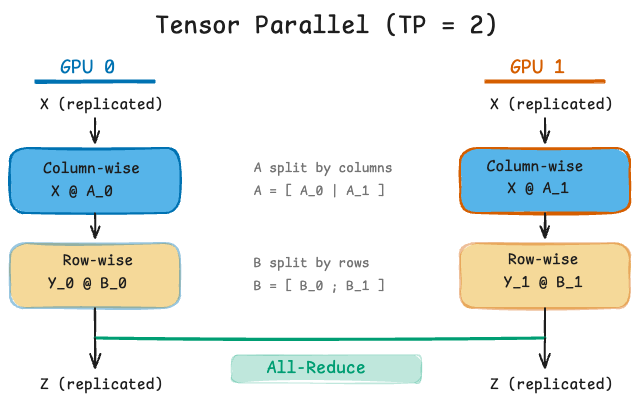

**Diagram 2: Sequence Parallel (SP)** — activations are sharded along the sequence dimension outside the TP region; the all-reduce is decomposed into an all-gather (before column-wise matmul) and a reduce-scatter (after row-wise matmul), saving activation memory.

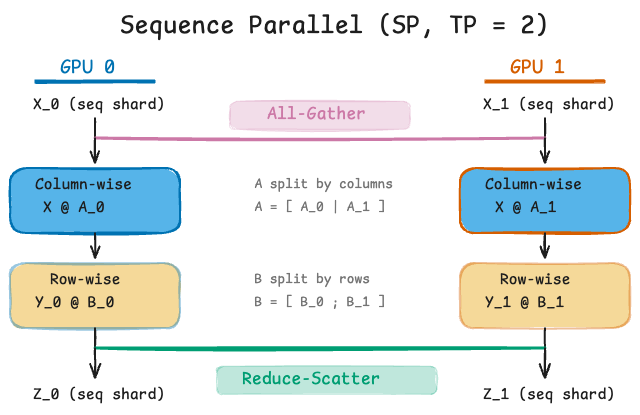

**Key insight:** Since All-Reduce = All-Gather + Reduce-Scatter, Sequence Parallel decomposes the all-reduce and places its two halves at opposite ends of the TP region. This avoids storing replicated activations, reducing memory usage.

**Key insight:** TP reduces the amount of replicated work each rank carries and shrinks the effective data-parallel grouping pressure. For example, with 4 GPUs and TP=2, each tensor-parallel group owns half of the matrix shards instead of keeping a full copy on every rank.

TP is best used **within a node** (NVLink bandwidth) since it requires per-layer communication.

**Resources:**
- [Ultra-Scale Playbook: Tensor Parallelism](https://huggingface.co/spaces/nanotron/ultrascale-playbook?section=tensor_parallelism)
- [PyTorch TP Tutorial](https://pytorch.org/tutorials/intermediate/TP_tutorial.html)
- [Small examples](https://github.com/pytorch/pytorch/blob/main/torch/distributed/tensor/examples/comm_mode_features_example.py)

Let’s now run Qwen3-4B with Tensor Parallel enabled through Megatron Core.


In [ ]:
# [DP + Tensor Parallel]
# TP=2 on 4 GPUs -> 2-way tensor parallel groups with the remaining dimension used for data parallelism
! CUDA_DEVICE_MAX_CONNECTIONS=1 torchrun --nproc-per-node=4 pretrain_qwen3_4b_lab.py \
    --tensor-parallel-size 2 \
    --sequence-parallel \
    --train-iters 10 \
    --micro-batch-size 1 \
    --global-batch-size 4 \
    --seq-length 2048 \
    --log-interval 1 \
    --recompute-granularity selective


**Diagram 3: DP + TP Composition**

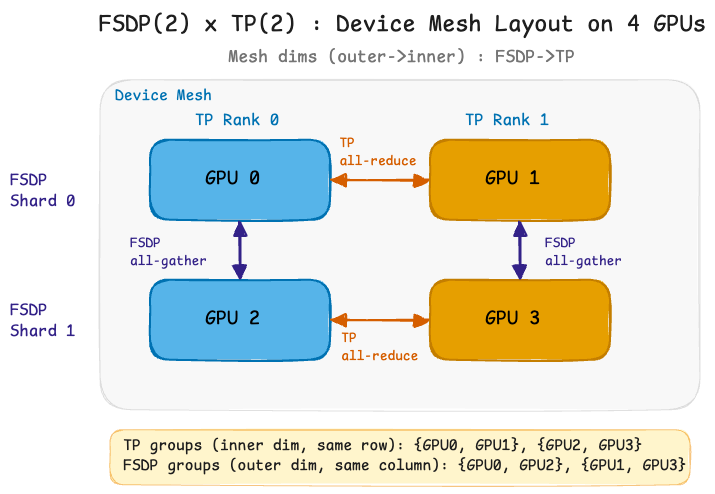

<div style="background: #f3e5f5; border-left: 4px solid #7b1fa2; padding: 12px 16px; margin: 12px 0; border-radius: 4px;">

### TP Summary

Splitting weight matrices across 2 GPUs lets each rank own only a shard of the TP-managed layers. At scale, this tradeoff is very favorable: TP communication stays inside the node while model-state pressure per rank drops substantially.

</div>

<div style="background: #f5f5f5; border-left: 4px solid #9e9e9e; padding: 10px 15px; margin: 10px 0; border-radius: 4px;">
  <strong style="color: #424242;">&#128278; Resources</strong>
  <ul style="margin: 6px 0 0 0; padding-left: 20px;">
    <li><a href="https://huggingface.co/spaces/nanotron/ultrascale-playbook?section=tensor_parallelism" style="color: #1565c0;">Ultra-Scale Playbook: Tensor Parallelism</a></li>
    <li><a href="https://arxiv.org/abs/1909.08053" style="color: #1565c0;">Megatron-LM Paper</a></li>
  </ul>
</div>

---

<div style="background: #e8f4fd; border-left: 4px solid #1976d2; padding: 10px 15px; margin: 10px 0; border-radius: 4px; font-size: 14px; color: #1565c0;">
  <strong>&#9201; ~8 min</strong> &mdash; Pipeline Parallel (PP)
</div>

### Apply Pipeline Parallel

<span style="color: #1565c0; font-weight: bold;">Pipeline Parallelism</span> splits model **layers into stages** across GPUs (inter-layer parallelism).

**How PP works in Megatron Core:**
- Stage 0 gets the first N layers, stage 1 gets the next N layers, and so on.
- **Forward:** inputs flow stage 0 → 1 → ... via point-to-point send/recv.
- **Backward:** gradients flow in reverse.
- Virtual pipeline stages can be added later to reduce pipeline bubbles further.

Megatron-LM's pipeline runtime is one of the core reasons it remains a reference implementation for very large training jobs.

**Diagram 4: Pipeline Parallel Schedules**

![image.png](…124149 tokens truncated…+moJCZSZLqlG87ByUE6aftsZpfFULAVJQNe7ZSEBEsgiAnCNgztcdxSbEro7+mIfJJAPBLB4dJCFfQP5UFQWO/nAhHMgARIggZwhUMHv3Zw5VxwoCZAACZBAbhAIJHxyYyocJQmQAAmQAAmQAAmQAAmQAAm0TYDCp20u3EsCJEACJEACJEACJEACJJBHBCh88uhkciokQAIkQAIkQAIkQAIkQAJtE6DwaZsL95IACZAACZAACZAACZAACeQRAQqfPDqZnAoJkAAJkAAJkAAJkAAJFBKBqnB54OlS+ARGxYokQAIk0H0EmM66+1izJxIgARIggcIgQOFTGOeZsyQBEiABEiABEiABEiCBgiZA4VPQp5+TJwESIAESIAESIAESIIHCIEDhUxjnmbMkARIgARIgARIgARIggYImQOFT0KefkycBEiABEsg0gWQCbTPdN9sjARIggUIj4IkXeMoUPoFRsSIJkAAJkAAJkAAJkAAJkECuEqDwydUzx3GTAAmQAAlkJYFk7j5m5QQ4KBIgARLIUwKBhE9FSaBqeYqI0yIBEiCB7idQUczv3e6nzh5JgARIgATymQB/WfP57HJuJEACJEACJEACJEACJEAChgCFDz8IJEACJJCFBLxoFg6KQyIBEiABEiCBHCZA4ZPDJ49DJwESIAESIAESIAESIAESCEaAwicYJ9YiARIgARIgARIgARIgARLIYQIUPjl88jh0EiABEiABEiABEiABEiCBYAQCC5+6zcEXBwrWNWuRAAmQAAmQAAmQAAmQAAmQQPcQCCx8umc47IUESIAESAAEGrbwZlMufhJ6hXtKbVN9Lg6dYyYBEiCBvCcQSPhUFjvS0MQUQ3n/aeAESYAESIAESIAESIAESCCHCNQ1NwYebSDhE7g1ViQBEiABEsgIAdxswk0nltwiEIl6sqG5IbcGzdGSAAmQQIEQSEr41G2m1adAPhecJgmQAAmQQBoEail+0qDHQ0mABEggOAFYfOBmHKQkJXyCNMg6JEACJEAC6RHATSaX387pQdxGR1cXlW+jntktCZAACZBAZwSS+mldURfprD2+TwIkQAIkQAIkQAIkQAIkQAJZRyCw8HHpap51J48DIgESyE8C9VvU4qPfuRWM8cnJE1wdLpcljatycuwcNAmQAAnkEgG4FbtOYDkjgWrixxduF4zxyaWPAsdKAiRAAiRAAiRAAiRAAvlLAMlkXP1XnekYH5tdiOInfz88nBkJkEB2EFjdEJHBVaHsGAxHkTSBmtIBJrMbExwkjY4HkAAJkECXEghk8cEI4HaxXWVIGOfTpeeDjZMACRQ4Ad5cyu0PQEgoWHP7DHL0JEACuURg+aZ1Mqx0YOAhBxY+uPuIlcT5oxyYLSuSAAmQQNIETHyPfjMPrgz89Zx0HzygawlUaYwPCuN8upYzWycBEihsAqlY1ZP+ZUW8D8VPYX/QOHsSIIGuJVBdwmwyXUu4a1sPOSH1N2da666lzNZJgAQKnQDie8JOOPAaPuAVWPhA8GAl8UEVdHcr9A8a508CJNB1BFbWR6SiJPBXc9cNhC2nRYBxPmnh48EkQAIk0CmB2qZ6UydoYgNUTurXtbrUvwtJi0+n54IVSIAESCBpAivqPBNPmfSBPCCrCIQT4nzo7pZVp4aDIQESyBMCcHNriGxJKr4HU09K+AypDskq3I2ku1uefGw4DRIggWwjgBtMjO/JtrOS3Hjg6oY4H7i7wRWDhQRIgARIILMETBrrJNbvsb0nJXwgeEJ6REWxy+xuliC3JEACJJAhAkhjXVWa1NdyhnpmM5kkgMxuED9wd0NZsml1JptnWyRAAiRQ8ASQzQ3r9wwrCZ7RDdCS/oXFj3LdZs8Ah1sGCwmQAAmQQPoE8H2K7Jm09qTPMhtaKHZ6xK0+dHfLhjPCMZAACeQLAXszKZk01nbuSQsfuGEgycHovmFZvjHCDG+WJLckQAIkkAYBfJ/W9Er6KzmNHnlodxCwVp9U0q52x/jYBwmQAAnkGgHcTEI2t2StPZhn0r+ycHfrXeaoq5vHBU1z7ZPC8ZIACWQlAXyf1vTmwpdZeXJSHJR1d7OxPvPrFgvFT4oweRgJkAAJxAjA2lPkFCWd1MACTFr44EAkOYAves8ezPJmQXJLAiRAAqkQgOihtScVctl/DNzdUKzVhy5v2X/OOEISIIHsJQDRg+/RfkXVKVl7MLOUhA+sPjsNCpsMb1zXJ3s/IBwZCZBAdhOIix5ae7L7RKU4Olh9bKyPXdfH+qan2CQPIwESIIGCJACLOURPsVucsrUH4FISPjjQuLyV+9ndkOVt4Zpm7GYhARIgARIIQCBR9DC2JwCwHK3SQ60+JsNbSX+T3ho/3HR5y9GTyWGTAAlsMwJwF4aL24jS7fS7tGfK40hZ+KDHIdWuFBf5fVP8pHwOeCAJkECBEbCiJ6xhPRQ9+X/yy5xSM8mdK4ZT/OT/6eYMSYAEMkzAxvWMKts+ZRc3O6S0hA8aQbzPmsaIaY/ix2LllgRIgATaJmBFj6vfvnAZZikMAmWuL36syxuTHRTGeecsSYAE0iPwkVp6YCnPhOjBSJyolvSG5B+9bKMnTert1qwaCOv8IN01CwmQAAmQgE+gbnPULPyMLSw9ED1wGWYpHAIRicjm6BaJRCNmUVP8mEMI1agbHAsJkAAJkMBWAjamZ2OkUUaXDjEublvfTf1ZxoQPhgDxs2RdRErDjlnfZ7vKkAyqSNuolPrseCQJkAAJbGMCVvDYYcA9eNwA3hiyPApxu0XFDwSQzVBE8VOInwLOmQRIoD0CED2wiruOK2PLatJ2b0vsJ6PCBw1D/CyrjUj/8pDUNnpSuylq1vuhAErEzuckQAKFQMC6tcGy46pxp6/eCBpcyZtBhXDuO5tja/GD+hRAnVHj+yRAAvlOwN4Q6lfUS0ZrTE86iQzaYpVx4WM7sQIIrm8oEEJY94euHT4PPpIACeQnAWvhwRZxPL1KHQnpdnBViN9/+XnK05oVBBDKwsalxo8dzymAQIGFBEigkAhYwQMrz8jSwTKqdPsumX6XCR87WgggFFiBIIIgfMqLXCkrogiyjLglARLIbQKJYqdahU7PHq40NnsUPLl9Wrt99BBBEEC1TfWyQV09IICqw+VSpf9ZSIAESCDfCNg4Hnzf9Smq1IVJe5ltpq08idy6XPjYznBhsFH/123yzBb7IYQQB+SpNhrQk+4fllWyW9xNZsleAhFf+2fvADmywATwPYZSv0W/yzSJC0pDk1p21I0N1p3qEsd8v1XqDR5aeAwePqRAAEkQFjeuMEeubaqVtU0bfQFU5K9dwWQIKUDlISRAAtucgF3DDIldUKzgGaXJCyB8uqN0m/BpPRkrhLAf1iBbPL2ugBCyLnGwDmFfZwUXHrb0TCFTUmfiARcy7RVc8KRbOus/3fZ5PAm0RSDTogx/u11RMjFO3Hixpb1xQtAkFogb+91Sp+9ZgWPr4LX9boDQQbHfXbYOtySQCQJfNi4XT/+tN9agepVG/u9m4p3RirCfMjsT/XVnG7BwsZAACaRHoCp2YyS9VrrmaPs3jgxtvXTxUVdCJktbSN3aEr/Duqb3lq1uM+HTchgtX9m7qtibeLHSslbbr2BRymRJtv9k+7YXTckeF7R+RUkGVFnQzrReV88niaGYqrwI7ZhY4t9axzVTezfVv59k/46T7aejz2l7fzNtHcPPV2qfCx6VGQIbmlsKhvWtXrfXy4YUhUbQ9tvrN9X9uFDKRKnOwIVhpsbS3nwi0cxew7TXD/fnPoEgf/+2jqtSI93S3me/o78rL/Z5hrjZFiKnrTlnpfBpa6D5sq8rLjSTvehLhmWyF6DJtG3rduX4bR/cdj+BtoRCkFG0JzwSjw3SNkVJIjE+J4FtS8BegKUyikwJrlQFX+KYMzUW22Z7F5P2/VS3HV2Mptpmqsd11RxTHU+mz2F740j18xZ0fEG4tvc56OjY7rbAtMevq/ZT+HQVWbabUwS6QpDmFAAdLIVCrp0xjpcESCDXCaQjCDuae9CL547ayNR7qQqATPXfup32xEDreum+7khcdNR2vguPjubeHe9R+HQHZfZBAiRAAiRAAiRAAiRAAiSwTQmk7/S3TYfPzkmABEiABEiABEiABEiABEigcwIUPp0zYg0SIAESIAESIAESIAESIIEcJ0Dhk+MnkMMnARIgARIgARIgARIgARLonACFT+eMWIMESIAESIAESIAESIAESCDHCVD45PgJ5PBJgARIgARIgARIgARIgAQ6J0Dh0zkj1iABEiABEiABEiABEiABEshxAv8Pk0vJoeCxT5kAAAAASUVORK5CYII=)


After applying TP, pipeline parallelism further reduces per-rank memory by assigning different layer ranges to different ranks. With 4 GPUs: **PP(2) × DP(2)** gives two pipeline stages, each replicated across a 2-way data-parallel group.

**Diagram 5: DP + PP Composition**

image.png


In [ ]:
# [DP + Pipeline Parallel]
# PP=2 on 4 GPUs -> 2 pipeline stages and 2-way data parallelism
! CUDA_DEVICE_MAX_CONNECTIONS=1 torchrun --nproc-per-node=4 pretrain_qwen3_4b_lab.py \
    --pipeline-parallel-size 2 \
    --train-iters 10 \
    --micro-batch-size 1 \
    --global-batch-size 4 \
    --seq-length 2048 \
    --log-interval 1 \
    --recompute-granularity full \
    --recompute-method uniform \
    --recompute-num-layers 1


---

<div style="background: #e8f4fd; border-left: 4px solid #1976d2; padding: 10px 15px; margin: 10px 0; border-radius: 4px; font-size: 14px; color: #1565c0;">
  <strong>&#9201; ~5 min</strong> &mdash; Context Parallel (CP)
</div>

### Apply Context Parallel

<span style="color: #1565c0; font-weight: bold;">Context Parallelism</span> splits the **sequence dimension** across GPUs, enabling training with very long sequences that would not fit on a single GPU.

**How CP works in Megatron Core:**
- Each rank holds a chunk of the sequence and its local KV state.
- Attention communication happens across the context-parallel group.
- The full logical sequence length is still the user-facing `seq_length`; CP changes how that work is partitioned.

**Key benefit:** enables sequence lengths that do not fit on a single GPU.

Let's run **DP(2) + CP(2)** with a longer sequence (16384 tokens, 8x our baseline):


In [ ]:
# [DP + Context Parallel]
# CP=2 on 4 GPUs -> each rank processes half the sequence length while attention KV communication happens across the CP group
! CUDA_DEVICE_MAX_CONNECTIONS=1 torchrun --nproc-per-node=4 pretrain_qwen3_4b_lab.py \
    --context-parallel-size 2 \
    --train-iters 10 \
    --micro-batch-size 1 \
    --global-batch-size 4 \
    --seq-length 16384 \
    --log-interval 1 \
    --recompute-granularity full \
    --recompute-method uniform \
    --recompute-num-layers 1


---

<div style="background: #e8f4fd; border-left: 4px solid #1976d2; padding: 10px 15px; margin: 10px 0; border-radius: 4px; font-size: 14px; color: #1565c0;">
  <strong>&#9201; ~3 min</strong> &mdash; Expert Parallel (EP) -- Bonus
</div>

### Expert Parallel Is for MoE Models

<span style="color: #1565c0; font-weight: bold;">Expert Parallelism</span> applies to **Mixture-of-Experts (MoE)** models, not to the dense Qwen3-4B recipe used in this notebook. Megatron Core supports MoE and expert parallelism, but switching from a dense GPT recipe to an MoE recipe changes the model architecture, router, and training config substantially.

For that reason, this lab keeps EP as a conceptual bonus topic rather than a runnable step.


If you want to explore EP later, start from a Megatron-LM MoE example instead of the dense Qwen3 recipe, then compose expert parallelism with TP, PP, and DP in the same way Megatron composes the other parallel dimensions.


<a id="step-2"></a>

---

<div style="background: #e8f4fd; border-left: 4px solid #1976d2; padding: 10px 15px; margin: 10px 0; border-radius: 4px; font-size: 14px; color: #1565c0;">
  <strong>&#9201; ~7 min</strong> &mdash; Activation Checkpointing
</div>

<h2>&#9889; Optimize Memory &amp; Compute</h2>

### Apply Activation Recomputation

When the memory footprint of activations becomes the next bottleneck, Megatron Core supports **activation recomputation** so activations do not need to stay fully materialized for the whole forward pass.


#### Activation Recomputation
Instead of storing every activation needed for backward, Megatron can selectively or fully recompute parts of the forward pass during backward. This trades extra FLOPs for lower peak memory and is one of the standard scaling levers for long-context or large-batch training.

**Diagram 9: Activation Checkpointing Memory Tradeoff (Study by Guyue Huang, NVIDIA)**

Screenshot 2026-02-13 at 5.35.20 PM.png


Megatron Bridge exposes this through recipe configuration. For a dense GPT-family model, the main choices are:

- `selective`: recompute the cheaper parts of each block while keeping the most expensive operations materialized.
- `full`: recompute the whole target region during backward.

Following is how one can apply activation recomputation in this lab:


```python
# Megatron Bridge recomputation controls used in this notebook:
#   --recompute-granularity full
#   --recompute-granularity selective
#   --recompute-method uniform
#
# Under the hood, these flags populate the Megatron Core transformer config
# for the Qwen3 recipe before the distributed training job launches.
```


In [ ]:
# [Full activation recomputation]
# full recomputation saves the most memory, at the cost of the most extra compute
! CUDA_DEVICE_MAX_CONNECTIONS=1 torchrun --nproc-per-node=4 pretrain_qwen3_4b_lab.py \
    --tensor-parallel-size 2 \
    --sequence-parallel \
    --train-iters 10 \
    --micro-batch-size 1 \
    --global-batch-size 4 \
    --seq-length 2048 \
    --log-interval 1 \
    --recompute-granularity full \
    --recompute-method uniform \
    --recompute-num-layers 1


#### Selective Activation Recomputation

Full recomputation reruns the entire target region in backward. Selective recomputation is more surgical: it preserves the most expensive work and recomputes the cheaper pieces around it, often giving a better memory/throughput tradeoff.

**Diagram 10: Full vs. Selective Activation Checkpointing**

image.png


In [ ]:
# [Selective activation recomputation]
# selective recomputation saves the most expensive activations and recomputes the rest during backward
! CUDA_DEVICE_MAX_CONNECTIONS=1 torchrun --nproc-per-node=4 pretrain_qwen3_4b_lab.py \
    --tensor-parallel-size 2 \
    --sequence-parallel \
    --train-iters 10 \
    --micro-batch-size 1 \
    --global-batch-size 4 \
    --seq-length 2048 \
    --log-interval 1 \
    --recompute-granularity selective


---

<div style="background: #e8f4fd; border-left: 4px solid #1976d2; padding: 10px 15px; margin: 10px 0; border-radius: 4px; font-size: 14px; color: #1565c0;">
  <strong>&#9201; ~5 min</strong> &mdash; Communication Overlap
</div>

### Apply Communication Overlap

Megatron Core can overlap communication with compute in both the tensor-parallel and data-parallel dimensions. On larger jobs, this is a major lever for reclaiming time that would otherwise be lost to all-reduce, reduce-scatter, and all-gather stalls.

In practice, you usually combine overlap with the distributed optimizer and tensor parallelism.

<div style="background: #fff8e1; border-left: 4px solid #ffb300; padding: 10px 15px; margin: 10px 0; border-radius: 4px; color: #8d6e00;">
  <strong>Lab Environment Note</strong><br>
  On this lab setup, Transformer Engine needs `UB_SKIPMC=1` so TP overlap falls back from CUDA Multicast to CUDA IPC.
</div>


In [ ]:
# [Communication overlap]
# overlap TP and DP communication with compute where possible
! UB_SKIPMC=1 CUDA_DEVICE_MAX_CONNECTIONS=1 torchrun --nproc-per-node=4 pretrain_qwen3_4b_lab.py \
    --tensor-parallel-size 2 \
    --sequence-parallel \
    --use-distributed-optimizer \
    --tp-comm-overlap \
    --overlap-grad-reduce \
    --overlap-param-gather \
    --train-iters 10 \
    --micro-batch-size 1 \
    --global-batch-size 4 \
    --seq-length 2048 \
    --log-interval 1 \
    --recompute-granularity selective


<a id="step-3"></a>

---

<div style="background: #e8f4fd; border-left: 4px solid #1976d2; padding: 10px 15px; margin: 10px 0; border-radius: 4px; font-size: 14px; color: #1565c0;">
  <strong>&#9201; ~5 min</strong> &mdash; Distributed Checkpointing
</div>

<h2>&#128737; Add Fault Tolerance</h2>

### Distributed Checkpointing

Megatron Bridge writes **distributed checkpoints** where each rank saves its shard. This keeps save and restore operations scalable as model and optimizer state grow.

Key config flags in this notebook:
- `--save PATH`: enable checkpointing to `PATH`
- `--save-interval N`: save every `N` steps
- `--load PATH`: resume from an existing distributed checkpoint

For this lab, we use a single synchronous save to keep disk usage manageable and produce one stable checkpoint artifact for resume and HF export. The resume example is a resume validation step: it loads that artifact, continues training, and stops without writing a second checkpoint.


In [ ]:
# [Checkpoint save demo]
! rm -rf /workspace/megatron-results/qwen3_4b/checkpoints
! CUDA_DEVICE_MAX_CONNECTIONS=1 torchrun --nproc-per-node=4 pretrain_qwen3_4b_lab.py \
    --train-iters 5 \
    --micro-batch-size 1 \
    --global-batch-size 4 \
    --seq-length 2048 \
    --log-interval 1 \
    --recompute-granularity selective \
    --save /workspace/megatron-results/qwen3_4b/checkpoints \
    --save-interval 5


In [ ]:
# [Resume training from an existing Megatron distributed checkpoint]
# load the saved checkpoint, continue training for one more iteration, and stop
! CUDA_DEVICE_MAX_CONNECTIONS=1 torchrun --nproc-per-node=4 pretrain_qwen3_4b_lab.py \
    --train-iters 6 \
    --micro-batch-size 1 \
    --global-batch-size 4 \
    --seq-length 2048 \
    --log-interval 1 \
    --recompute-granularity selective \
    --load /workspace/megatron-results/qwen3_4b/checkpoints/iter_0000005


<a id="training-summary"></a>

<div style="background: #f3e5f5; border-left: 4px solid #7b1fa2; padding: 12px 16px; margin: 12px 0; border-radius: 4px;">

## Training Summary

### How parallelism techniques compose

On this 4-GPU lab system, Megatron-LM lets us explore the same parallel dimensions used in much larger production jobs:

- Start with **data parallelism** for the simplest baseline.
- Add **tensor parallelism** to split large matmuls inside each layer.
- Add **pipeline parallelism** to divide the layer stack across ranks.
- Add **context parallelism** to support much longer sequences.
- Use **activation recomputation** and **communication overlap** to reclaim memory and throughput.
- Use **distributed checkpoints** so the run can be saved and resumed cleanly.

This is the core Megatron pattern: use the minimum parallel dimensions needed to fit and saturate the job, then layer on runtime optimizations once the topology is stable.

### Where to go next

- Replace the mock-data recipe with a real dataset and tokenizer pipeline.
- Adapt the same entrypoints for finetuning or larger Qwen recipes on bigger GPU topologies.
- Use the checkpointing and resume flow here as the baseline for longer-running training jobs.
- Consult the [Megatron Bridge performance summary](https://docs.nvidia.com/nemo/megatron-bridge/latest/performance-summary.html) for hardware-specific performance numbers and starting configurations.

### Acknowledgements

This notebook adapts an earlier TorchTitan-based version of the lab into a Megatron Core and Megatron Bridge workflow. The structure and teaching approach are also informed by Hugging Face's [Ultra-Scale Playbook](https://huggingface.co/spaces/nanotron/ultrascale-playbook?section=high-level_overview).

### Further Reading

- [Megatron Bridge Parallelisms](https://docs.nvidia.com/nemo/megatron-bridge/latest/parallelisms.html)
- [Megatron Bridge Performance Summary](https://docs.nvidia.com/nemo/megatron-bridge/latest/performance-summary.html)
- [Megatron Core FSDP guide](https://docs.nvidia.com/megatron-core/developer-guide/latest/api-guide/custom_fsdp.html)
- [Megatron Bridge Communication Overlap](https://docs.nvidia.com/nemo/megatron-bridge/latest/training/communication-overlap.html)
- [Ultra-Scale Playbook](https://huggingface.co/spaces/nanotron/ultrascale-playbook?section=high-level_overview)

</div>
